# Fig: Distribution of last h_actual in mismatch agentLower scenario: pmax_th=0.95

Reference: 
- `20260531_fig_infotaxis_MAP_cmp_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from plot_utils import bar_violinplot_last_h_actual
from simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  926
Mean:    left: 0.122  right: 0.120
Median:  left: 0.120  right: 0.119

MWU test
 - different: 0.37719
 - less:      0.81143
 - greater:   0.18860
--------------------------------------------
Samples: left:  989    right:  832
Mean:    left: 0.122  right: 0.123
Median:  left: 0.120  right: 0.120

MWU test
 - different: 0.88148
 - less:      0.44074
 - greater:   0.55930
--------------------------------------------
Samples: left:  989    right:  618
Mean:    left: 0.122  right: 0.121
Median:  left: 0.120  right: 0.119

MWU test
 - different: 0.92420
 - less:      0.46210
 - greater:   0.53794
--------------------------------------------
Samples: left:  989    right:  245
Mean:    left: 0.122  right: 0.135
Median:  left: 0.120  right: 0.134

MWU test
 - different: 0.00004
 - less:      0.00002
 - greater:   0.99998
--------------------------------------------


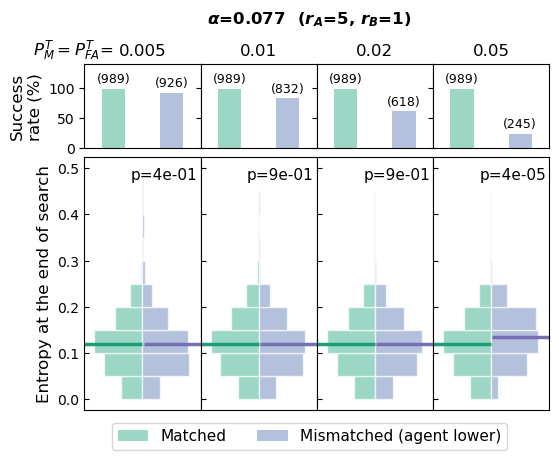

Samples: left:  977    right:  890
Mean:    left: 0.173  right: 0.173
Median:  left: 0.163  right: 0.164

MWU test
 - different: 0.85136
 - less:      0.42568
 - greater:   0.57435
--------------------------------------------
Samples: left:  977    right:  738
Mean:    left: 0.173  right: 0.180
Median:  left: 0.163  right: 0.173

MWU test
 - different: 0.11945
 - less:      0.05972
 - greater:   0.94029
--------------------------------------------
Samples: left:  977    right:  460
Mean:    left: 0.173  right: 0.179
Median:  left: 0.163  right: 0.177

MWU test
 - different: 0.14257
 - less:      0.07129
 - greater:   0.92873
--------------------------------------------
Samples: left:  977    right:  109
Mean:    left: 0.173  right: 0.174
Median:  left: 0.163  right: 0.178

MWU test
 - different: 0.58469
 - less:      0.29235
 - greater:   0.70776
--------------------------------------------


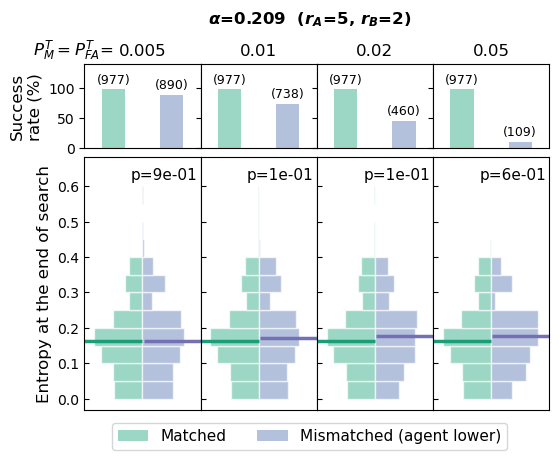

Samples: left:  986    right:  886
Mean:    left: 0.170  right: 0.173
Median:  left: 0.148  right: 0.164

MWU test
 - different: 0.55657
 - less:      0.27828
 - greater:   0.72175
--------------------------------------------
Samples: left:  986    right:  707
Mean:    left: 0.170  right: 0.167
Median:  left: 0.148  right: 0.148

MWU test
 - different: 0.63896
 - less:      0.68055
 - greater:   0.31948
--------------------------------------------
Samples: left:  986    right:  344
Mean:    left: 0.170  right: 0.189
Median:  left: 0.148  right: 0.174

MWU test
 - different: 0.00469
 - less:      0.00234
 - greater:   0.99766
--------------------------------------------
Samples: left:  986    right:   91
Mean:    left: 0.170  right: 0.188
Median:  left: 0.148  right: 0.180

MWU test
 - different: 0.06395
 - less:      0.03197
 - greater:   0.96805
--------------------------------------------


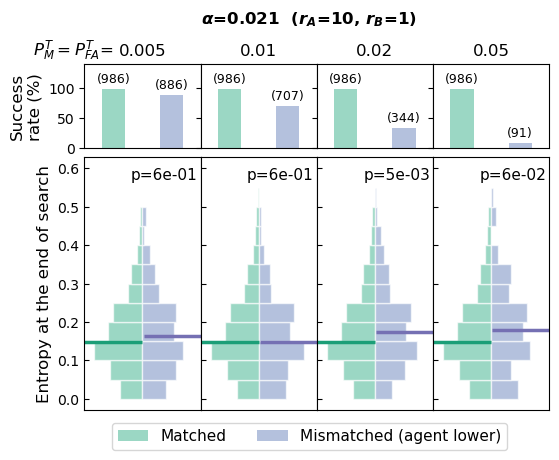

Samples: left:  980    right:  862
Mean:    left: 0.179  right: 0.180
Median:  left: 0.165  right: 0.168

MWU test
 - different: 0.72335
 - less:      0.36168
 - greater:   0.63836
--------------------------------------------
Samples: left:  980    right:  620
Mean:    left: 0.179  right: 0.178
Median:  left: 0.165  right: 0.167

MWU test
 - different: 0.97714
 - less:      0.48857
 - greater:   0.51147
--------------------------------------------
Samples: left:  980    right:  265
Mean:    left: 0.179  right: 0.169
Median:  left: 0.165  right: 0.160

MWU test
 - different: 0.19454
 - less:      0.90276
 - greater:   0.09727
--------------------------------------------
Samples: left:  980    right:   33
Mean:    left: 0.179  right: 0.169
Median:  left: 0.165  right: 0.165

MWU test
 - different: 0.88481
 - less:      0.55784
 - greater:   0.44240
--------------------------------------------


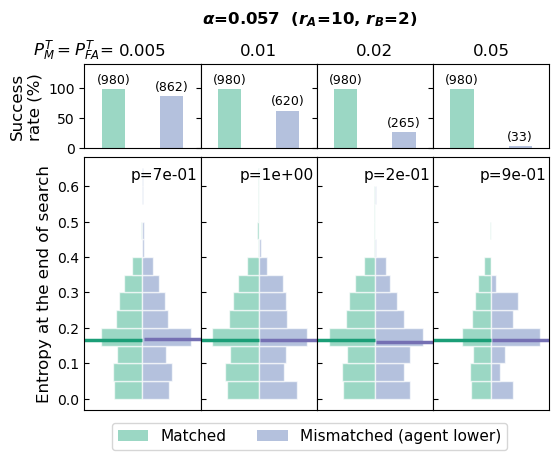

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_truth_all = [0.005, 0.01, 0.02, 0.05]
pm_agent_all = [0.001] * len(pm_truth_all)


for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_infotaxis_mismatch_agentLower_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for pm_agent, pm_truth in zip(pm_agent_all, pm_truth_all):
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="mismatch",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent, pm_truth=pm_truth
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        
        fig = bar_violinplot_last_h_actual(
            cr=cr, br=br, pm_all=pm_truth_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Matched", y_str="Mismatched (agent lower)",
            comparison_type="agent_lower",
            stats_type="two-sided",
            bar_step=0.05,
            crowded_bars=False,
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            color_idx_left=0, color_idx_right=2,
            alpha=0.65
        )

        fig.savefig(
            path_fig / f"fig_last_h_actual_mismatch_agentLower_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )